<a href="https://colab.research.google.com/github/juvereturn05151/cs576-Deep-Learning/blob/main/Project%232_Ju-veChankasemporn/animals10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Programming Assignment 2 CNN and data competition**

In [16]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Animals10

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Animals10


**Load and Visualize the sample(Animals 10)**

In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, regularizers
import pathlib

IMG_SIZE = (224, 224)
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE
SEED = 123
tf.random.set_seed(SEED)
np.random.seed(SEED)
print(tf.config.list_physical_devices())
print("TF version:", tf.__version__)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.19.0


DATA_DIR exists: True
Classes (folders): ['cane', 'cavallo', 'farfalla', 'elefante', 'gallina', 'mucca', 'gatto', 'pecora', 'scoiattolo', 'ragno']
Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Class names: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Num classes: 10


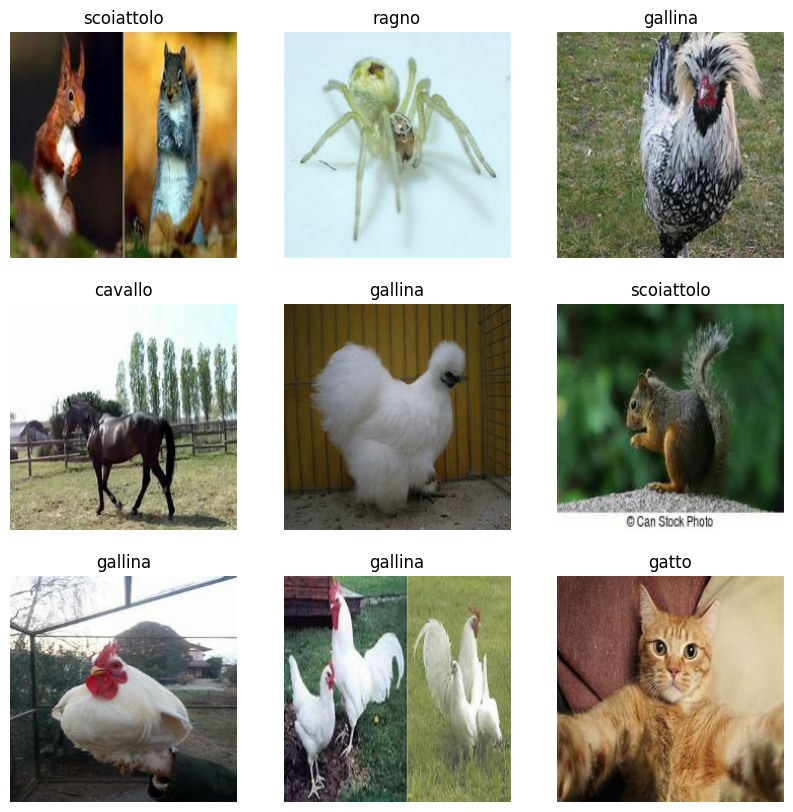

In [18]:
DATA_DIR = pathlib.Path("/content/drive/MyDrive/Animals10/raw-img")
print("DATA_DIR exists:", DATA_DIR.exists())
print("Classes (folders):", [p.name for p in DATA_DIR.iterdir() if p.is_dir()])

class_counts = {}
for cls_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    count = len(list(cls_dir.glob("*")))
    class_counts[cls_dir.name] = count

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Num classes:", num_classes)

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.show()

**Necessary Functions**

In [19]:
#data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
])

#callbacks
early_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

early_cb2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)
lr_cb2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1
)

**Construct a CNN**

In [ ]:
#CNN model
CNN_model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same", use_bias=False,kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, 3, padding="same", use_bias=False,kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.20),

    layers.Conv2D(64, 3, padding="same", use_bias=False,kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, 3, padding="same", use_bias=False,kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, padding="same", use_bias=False,kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(128, 3, padding="same", use_bias=False,kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.30),

    layers.Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(5e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.35),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.40),
    layers.Dense(num_classes, activation="softmax"),
])

CNN_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

CNN_model.summary()

print("\nBASELINE CNN: Training from scratch")
CNN_history = CNN_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=[early_cb, lr_cb],
    verbose=1
)

CNN_val_loss, CNN_val_acc = CNN_model.evaluate(val_ds, verbose=0)
print(f"\nBaseline VAL Accuracy: {CNN_val_acc:.4f} | VAL Loss: {CNN_val_loss:.4f}")

**Contruct Efficient Net + CNN**

In [ ]:
#build model with EfficientNetB0 backbone
efficient_net_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
efficient_net_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs, training=True)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = efficient_net_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

improved_cnn_model = tf.keras.Model(inputs, outputs)

improved_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_cnn_model.summary()

print("\nPhase 1: Training head with frozen backbone")
improved_cnn_history_phase1 = improved_cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_cb, lr_cb]
)

print("\nPhase 2: Fine-tuning full model")
efficient_net_model.trainable = True
improved_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_cnn_history_phase2 = improved_cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_cb2, lr_cb2]
)

val_loss, val_acc = improved_cnn_model.evaluate(val_ds, verbose=0)
print(f"\nEfficientNet VAL Accuracy: {val_acc:.4f} | Test Loss: {val_loss:.4f}")

**Visualize Comparison**

In [ ]:
#CNN curves
b_acc = CNN_history.history["accuracy"]
b_val = CNN_history.history["val_accuracy"]

#efficientNet curves
p1_acc = improved_cnn_history_phase1.history["accuracy"]
p2_acc = improved_cnn_history_phase2.history["accuracy"]
p1_val = improved_cnn_history_phase1.history["val_accuracy"]
p2_val = improved_cnn_history_phase2.history["val_accuracy"]

eff_acc = p1_acc + p2_acc
eff_val = p1_val + p2_val
split = len(p1_acc)

plt.plot(b_acc, label="Baseline Train Acc")
plt.plot(b_val, label="Baseline Val Acc")
plt.plot(eff_acc, label="EffNet Train Acc")
plt.plot(eff_val, label="EffNet Val Acc")
plt.axvline(x=split, color="gray", linestyle="--", label="EffNet fine-tune start")
plt.title("Accuracy: Baseline CNN vs EfficientNet Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Use CNN to predict the image labels (Animals 10)**

In [ ]:
for images, labels in val_ds.take(1):
    fixed_images = images
    fixed_labels = labels
    break

CNN_model_preds = CNN_model.predict(fixed_images)
CNN_model_pred_classes = np.argmax(CNN_model_preds, axis=1)

plt.figure(figsize=(40,40))
plt.suptitle("Convolutional Neural Network Predictions", fontsize=40)

for i in range(20):
    plt.subplot(10,10,i+1)
    plt.imshow(fixed_images[i].numpy().astype("uint8"))
    plt.title(f"True: {class_names[fixed_labels[i]]}\nPred: {class_names[CNN_model_pred_classes[i]]}")
    plt.axis("off")

plt.show()

**Use Efficient Net to predict the image labels (Animals 10)**

In [ ]:
for images, labels in val_ds.take(1):
    fixed_images = images
    fixed_labels = labels
    break

improved_cnn_preds = improved_cnn_model.predict(fixed_images)
improved_cnn_pred_classes = np.argmax(improved_cnn_preds, axis=1)

plt.figure(figsize=(40,40))
plt.suptitle("Improved Convolutional Neural Network Predictions", fontsize=40)

for i in range(20):
    plt.subplot(10,10,i+1)
    plt.imshow(fixed_images[i].numpy().astype("uint8"))
    plt.title(f"True: {class_names[fixed_labels[i]]}\nPred: {class_names[improved_cnn_pred_classes[i]]}")
    plt.axis("off")

plt.show()